# Setup & Imports

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent 
sys.path.append(str(PROJECT_ROOT))

from typing import cast

from src.data.loader import load_data, train_test_split
from src.data.preprocess import preprocessing_pipeline, create_labels
from src.data.transformers import DropFeatureSelector
from src.features.features import feature_engineering_pipeline
from src.training.training import training_pipeline, fine_tune, feature_selection_pipeline
from src.evaluation.metrics import feature_importance, cross_validation, evaluation_metrics, print_metrics
from src.evaluation.plots import plot_feature_importance, plot_roc_curve, plot_confusion_matrix
from src.utils.utils import get_best_estimator, TSCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [ ]:
df = load_data()
create_labels(df)
X_train, X_test, y_train, y_test = train_test_split(df)
prep_pipeline : Pipeline = preprocessing_pipeline(X_train, y_train)
feat_pipeline : Pipeline = feature_engineering_pipeline()

preprocessor = Pipeline(
    steps=[
        ("preprocessing", prep_pipeline),
        ("feature_engineering", feat_pipeline),
    ]
)

# Training & Fine Tuning

Firstly the we add the Random Forest Classifier as a step for the pipeline, then the `fine_tune()` method is used to find the best hyperparameters using a `RandomizedSearchCV`, finally the pipeline is fitted with the training data. 

In [ ]:
random_forest_train_pipeline = training_pipeline(model=RandomForestClassifier(random_state=42))

pipeline = Pipeline(
    steps = preprocessor.steps + random_forest_train_pipeline.steps
)

hyperparams = {
        'training__n_estimators': [100, 200, 300],
        'training__max_depth': [None, 10, 20],
        'training__min_samples_split': [2, 5, 10],
        'training__min_samples_leaf': [1, 2, 4]
    }

search_rf = fine_tune(
    pipeline=pipeline,
    tuning_methods=RandomizedSearchCV,
    tscv=TSCV,
    hyperparams=hyperparams,
    scoring="accuracy",
    verbose=1,
    random_state=42
    )

search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [ ]:
best_estimator = get_best_estimator(search_rf)

cross_val_scores = cross_validation(
        pipeline=best_estimator,
        X=X_train,
        y=y_train,
        tscv=TSCV,
        verbose=0,
        scoring="accuracy"
    )

print(pd.Series(cross_val_scores).describe())

count    5.000000
mean     0.674611
std      0.005806
min      0.668923
25%      0.669939
50%      0.673324
75%      0.678064
max      0.682803
dtype: float64


## Feature Selection

In [5]:
importances = feature_importance(
    pipeline=best_estimator,
    X=X_train
)

importances

,importance
max_bet_diff,0.218152
avg_bet_diff,0.208262
weighted_ranking_diff,0.089325
rank_diff,0.065839
last_k_sets_win_rate_diff,0.061140
...,...
Tournament_Chennai Open,0.000068
Tournament_Mifel Open,0.000061
Tournament_Hong Kong Tennis Open,0.000052
Tournament_Sydney Tennis Classic,0.000043


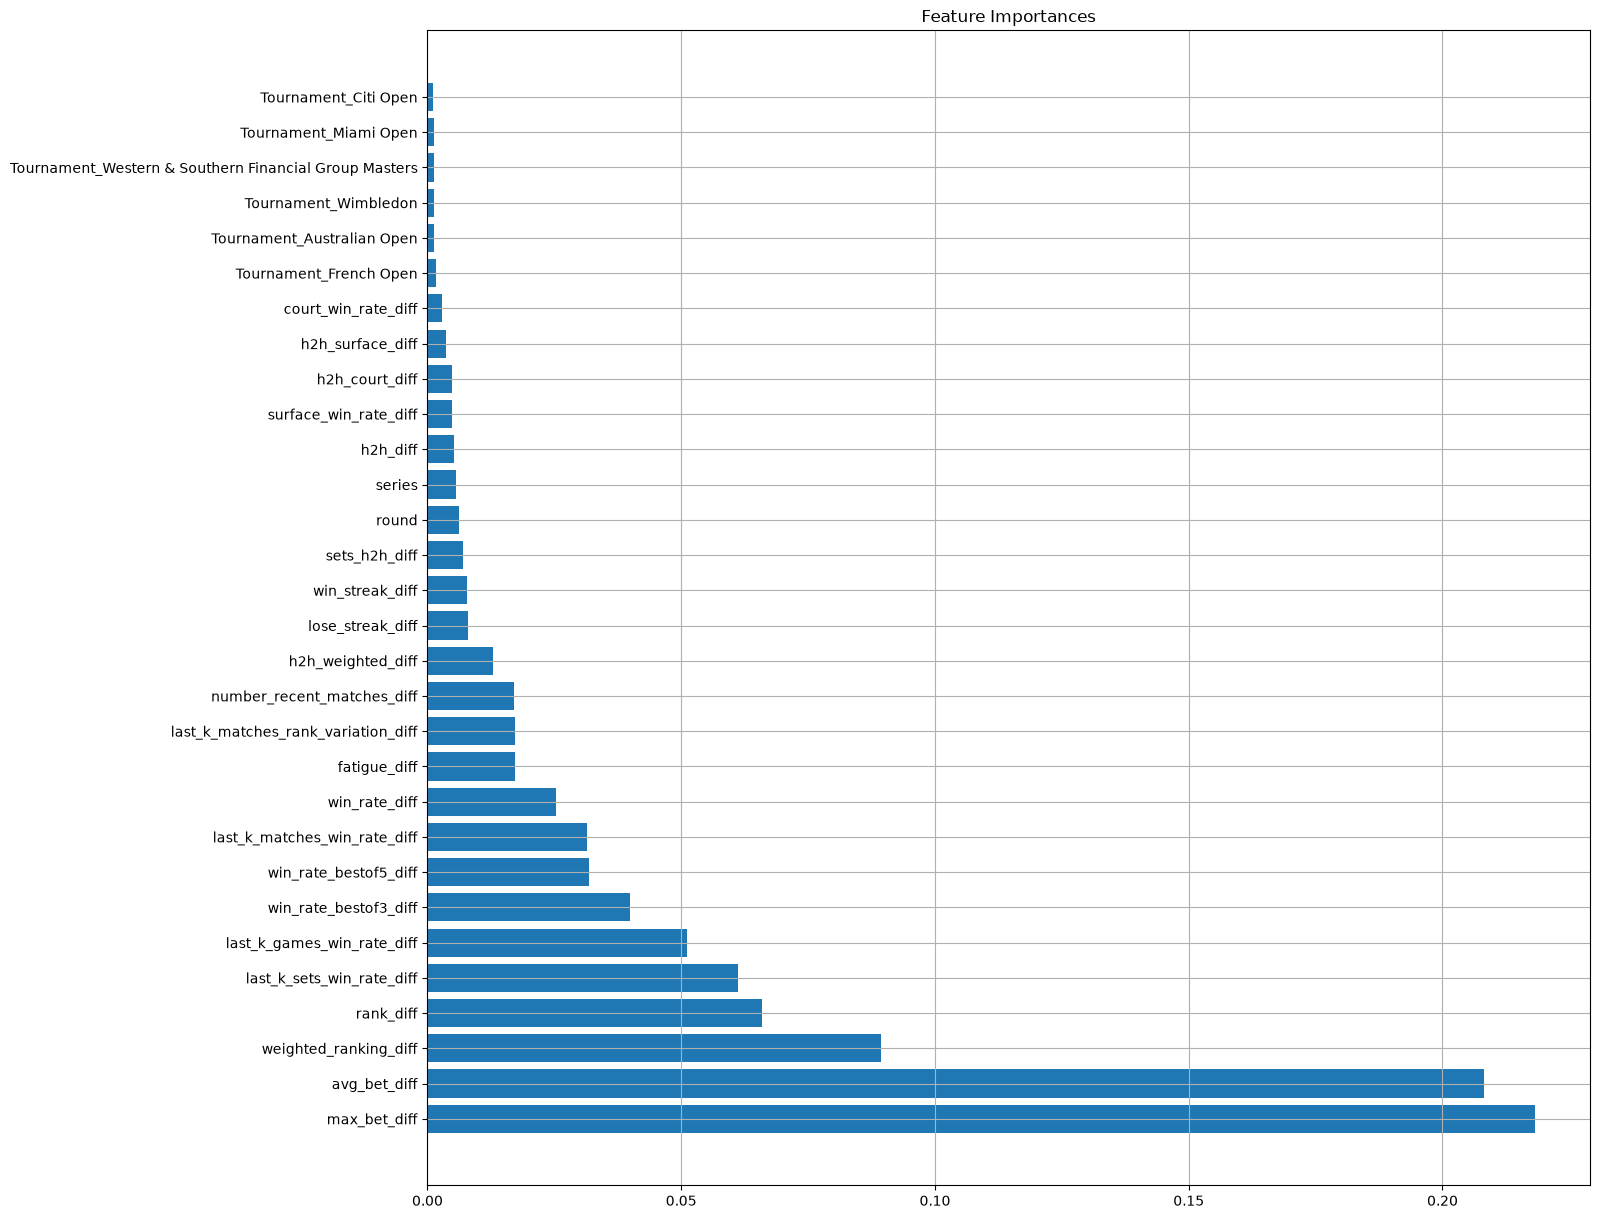

In [6]:
plot_feature_importance(
    feature_names=importances.index.tolist(),
    feature_importances=importances["importance"],
    top_n=30
)

In [ ]:
pipeline = Pipeline(
        steps= preprocessor.steps + [
            ("drop_tournaments", DropFeatureSelector(features_to_drop=["Tournament_"], is_grouped=True)),
            ] + random_forest_train_pipeline.steps
    )

search_rf : RandomizedSearchCV | GridSearchCV = fine_tune(
    pipeline=pipeline,
    tuning_methods=RandomizedSearchCV,
    tscv=TSCV,
    hyperparams=hyperparams,
    scoring="accuracy",
    verbose=1,
    random_state=42
    )

search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [ ]:
best_estimator = get_best_estimator(search_rf)

cross_val_scores = cross_validation(
        pipeline=best_estimator,
        X=X_train,
        y=y_train,
        tscv=TSCV,
        verbose=0,
        scoring="accuracy"
    )

print(pd.Series(cross_val_scores).describe())

count    5.000000
mean     0.673595
std      0.005219
min      0.667569
25%      0.670616
50%      0.673324
75%      0.675017
max      0.681449
dtype: float64


In [9]:
rcevf_pipeline = feature_selection_pipeline(
    model=RandomForestClassifier(random_state=42),
    tscv=TSCV
)

pipeline = Pipeline(
    steps= preprocessor.steps + [
                ("drop_tournaments", DropFeatureSelector(features_to_drop=["Tournament_"], is_grouped=True)),
                ("fs", rcevf_pipeline),
            ]
    )

X_train_rcevf = pipeline.fit_transform(X_train, y_train)

In [ ]:
search_rf = fine_tune(
    pipeline=random_forest_train_pipeline,
    tuning_methods=RandomizedSearchCV,
    tscv=TSCV,
    hyperparams=hyperparams,
    scoring="accuracy",
    verbose=1,
    random_state=42
)

search_rf.fit(X_train_rcevf, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [ ]:
best_estimator = get_best_estimator(search_rf)

full_pipeline_rf = Pipeline(
    steps= preprocessor.steps + [
            ("drop_tournaments", DropFeatureSelector(features_to_drop=["Tournament_"], is_grouped=True))
        ] + best_estimator.steps
    )

full_pipeline_rf.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('feature_engineering', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('fix_typos', ...), ('drop_cols', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,column,'Comment'


In [12]:
cross_val_scores = cross_validation(
        pipeline=full_pipeline_rf,
        X=X_train,
        y=y_train,
        tscv=TSCV,
        verbose=0,
        scoring="accuracy"
    )

print(pd.Series(cross_val_scores).describe())

count    5.000000
mean     0.673595
std      0.005219
min      0.667569
25%      0.670616
50%      0.673324
75%      0.675017
max      0.681449
dtype: float64


# Evaluation

In [13]:
y_pred = full_pipeline_rf.predict(X_test)

We are interested in accuracy most.

In [14]:
metrics : dict = evaluation_metrics(
    model=full_pipeline_rf,
    X_test=X_test,
    y_test=y_test,
    y_pred=y_pred
)

print_metrics(metrics)


Accuracy:
0.6839

Roc Auc:
0.7425

F1:
0.6741

Recall:
0.6717

Confusion Matrix:
      0     1
0  1594   698
1   713  1459


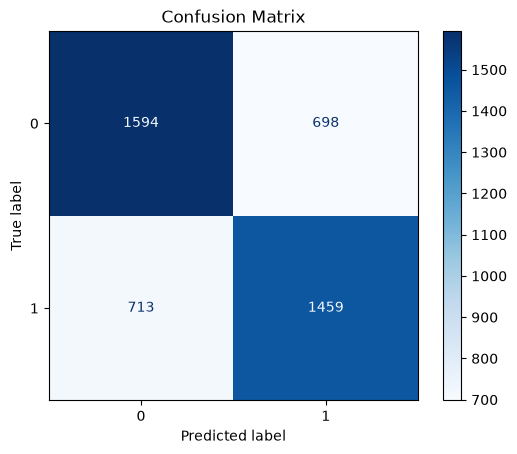

In [15]:
plot_confusion_matrix(cm=metrics["confusion_matrix"])

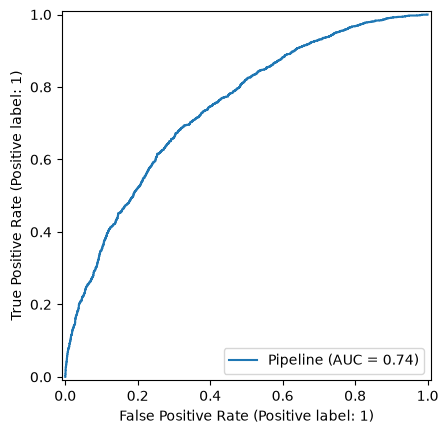

In [16]:
plot_roc_curve(
    model=full_pipeline_rf,
    X_test=X_test,
    y_test=y_test
)

In [17]:
wrong = np.asarray(y_pred) != np.asarray(y_test)
errors = X_test.loc[wrong].copy()
errors["y_true"] = np.asarray(y_test)[wrong]
errors["y_pred"] = np.asarray(y_pred)[wrong]

errors["y_true"].describe().transpose()

count    1411.000000
mean        0.505315
std         0.500149
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: y_true, dtype: float64

In [18]:
proba = full_pipeline_rf.predict_proba(X_test)[:, 1]
errors["proba_pos"] = proba[wrong]

# false positives vs false negatives
fp = errors[(errors.y_true == 0) & (errors.y_pred == 1)] # player_2 actually won
fn = errors[(errors.y_true == 1) & (errors.y_pred == 0)] # player_1 actually won

fp.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
ATP,698.0,35.213467,1.0,25.0,37.0,48.0,65.0,15.918155
Date,698,2025-01-23 19:13:14.269341,2024-04-09 00:00:00,2024-08-12 00:00:00,2025-02-15 12:00:00,2025-06-30 00:00:00,2025-11-13 00:00:00,NaN
Best of,698.0,3.332378,3.0,3.0,3.0,3.0,5.0,0.745034
player1_Rank,698.0,52.005731,1.0,17.0,39.0,68.0,617.0,56.014806
player2_Rank,698.0,101.30086,2.0,45.0,68.0,115.0,937.0,111.014151
player1_Pts,698.0,1918.164756,57.0,820.25,1270.5,2415.0,11480.0,1739.724045
player2_Pts,698.0,1009.282235,17.0,529.0,817.0,1148.75,9590.0,944.093809
player1_B365,695.0,1.512144,1.01,1.33,1.53,1.67,2.63,0.238273
player2_B365,695.0,3.031986,1.5,2.2,2.5,3.4,29.0,1.691287
player1_BFE,93.0,1.58043,1.14,1.37,1.57,1.76,2.2,0.244131


In [19]:
# plt.hist(fp["player1_Rank"], bins=100, range=(1, 200), alpha=0.5, label='Loser Rank')
# plt.hist(fp["player2_Rank"], bins=100, range=(1, 200), alpha=0.5, label='Winner Rank')

# plt.xlabel('Ranking')
# plt.ylabel('Frequency')
# plt.title('Winner - Loser Ranking')
# plt.legend()

# plt.show()

In [20]:
# plot_difference(
#     dataframe=fp,
#     first_col="player1_Rank",  
#     second_col="player2_Rank",
# )